In [1]:
import os
import cv2
import numpy as np
import torch
import gc
import time
import torch
from realesrgan.archs.rrdb_unet_arch import RRDB_UNet
from realesrgan.archs.rrdb_unet_res_arch import RRDB_UNet_res

In [2]:
pad = 8
#device = "cuda"
device = "cpu"

In [3]:
model = RRDB_UNet_res(
    num_in_ch=3,
    num_out_ch=3,
    highway_channels_base=24,
    processing_channels_base=12,
    num_grow_ch_base = 6,
    ae_rrdb_blocks=1,
    ae_channel_multipliers = [1,2,4,8,8],
    use_attention=True,
    body_rrdb_blocks = 4
)

highway_channels_base 24
processing_channels_base 12
num_grow_ch_base 6
ae_rrdb_blocks 1
ae_channel_multipliers [1, 2, 4, 8, 8]
use_attention True
body_rrdb_blocks 4


In [4]:
print(model)

RRDB_UNet_res(
  (encoder): ModuleList(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.01, inplace=True)
    (2): HighwayRRDB(
      (compress): Conv2d(24, 12, kernel_size=(1, 1), stride=(1, 1))
      (rdb1): ResidualDenseBlock(
        (conv1): Conv2d(12, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(18, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv3): Conv2d(24, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv4): Conv2d(30, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv5): Conv2d(36, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (lrelu): LeakyReLU(negative_slope=0.2, inplace=True)
      )
      (rdb2): ResidualDenseBlock(
        (conv1): Conv2d(12, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv2): Conv2d(18, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (conv3): Conv2d(24, 6,

In [5]:
img = cv2.imread("tests/data/lq_4/comic.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#img = cv2.resize(img, (4020*4, 4020*1))
#img = cv2.resize(img, (200,200))
scale = 4
img = cv2.resize(img, (img.shape[1]*scale,img.shape[0]*scale))
print(img.shape)

(360, 240, 3)


In [6]:
from realesrgan.real_esrganer_1x import RealESRGANer1x

#esrganer = RealESRGANer1x(None, model, pad, device)
esrganer = RealESRGANer1x("experiments/train_unet_dynamic_iterative_res_xs/models/net_g_latest.pth", model, pad, device)

In [7]:
out = esrganer.enhance(img)[0]
out.shape

(360, 240, 3)

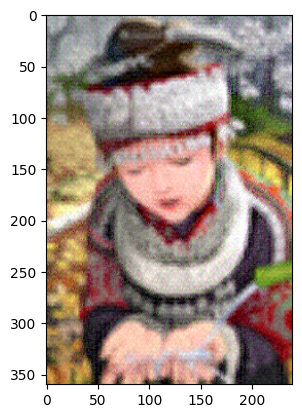

In [8]:
import matplotlib.pyplot as plt
plt.imshow(out)

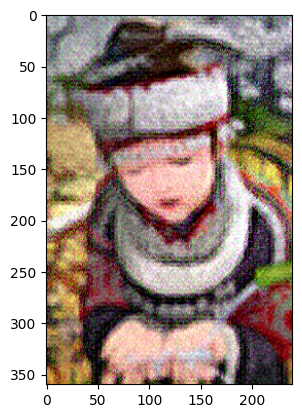

In [9]:
out = esrganer.enhance(out)[0]
plt.imshow(out)

In [ ]:
out = esrganer.enhance(out)[0]
plt.imshow(out)

In [ ]:
exit()